# 实战 Case 4: NLP 自我练习 - 电商客服对话分析 (XGBoost + K-Means) 🥋

## 🎯 练习目标 (Mission)
这是您的 **"毕业考试"**。请不依赖之前的 Notebook，独立完成以下任务：
1.  **数据清洗**: 处理多语言文本 (EN/PT/ES/AR/ZH-TW)，去除噪音。
2.  **特征工程**: 使用 **TF-IDF** 将文本向量化 (注意：英文自带空格，中文需要分词，可以使用 `jieba` 处理中文部分，或者直接让 `TfidfVectorizer` 处理)。
3.  **监督学习 (XGBoost)**: 训练一个分类器，预测用户的**意图 (Intent)**。
4.  **无监督学习 (K-Means)**: 尝试聚类，看看能发现什么新的模式。

---

In [1]:
# 0. 数据生成 (Multilingual 某跨境电商S公司-style Data) - 请直接运行此 Cell
import pandas as pd
import random

# 模拟 某跨境电商S公司 全球用户评论 (EN, PT, ES, AR, ZH-TW)
# 标签: Refund, Logistics, Product, Complaint
multilingual_keywords = {
    'en': {
        'refund': ['refund', 'money back', 'return this', 'cancel order', 'where is my money'],
        'logistics': ['shipping', 'delivery', 'arrived', 'package', 'tracking', 'late', 'stuck', 'courier'],
        'product': ['quality', 'size', 'fabric', 'color', 'looks cheap', 'beautiful', 'wrong item', 'ripped'],
        'complaint': ['terrible service', 'worst experience', 'customer support', 'rude', 'cheat', 'scam', 'useless']
    },
    'pt': { # 巴西 (Brazil) 是 某跨境电商S公司 大市场
        'refund': ['reembolso', 'devolver', 'dinheiro de volta', 'cancelar', 'estorno', 'quero meu dinheiro'],
        'logistics': ['entrega', 'correios', 'pacote', 'rastreio', 'demora', 'chegou', 'atrasado', 'não recebi'],
        'product': ['qualidade', 'tamanho', 'tecido', 'cor', 'feio', 'lindo', 'produto errado', 'rasgado'],
        'complaint': ['péssimo serviço', 'atendimento', 'horrível', 'fraude', 'enganada', 'lixo']
    },
    'es': { # 拉美/西班牙
        'refund': ['reembolso', 'devolución', 'dinero', 'cancelar pedido', 'retorno', 'quiero mi dinero'],
        'logistics': ['envío', 'entrega', 'paquete', 'seguimiento', 'tarda mucho', 'llegó', 'retraso'],
        'product': ['calidad', 'talla', 'tela', 'color', 'feo', 'bonito', 'artículo incorrecto', 'roto'],
        'complaint': ['servicio terrible', 'peor experiencia', 'atención al cliente', 'estafa', 'mentirosos']
    },
    'ar': { # 中东 (Middle East)
        'refund': ['استرداد', 'إرجاع', 'نقود', 'إلغاء', 'فلوس', 'اريد مالي'],
        'logistics': ['شحن', 'توصيل', 'طرد', 'تتبع', 'تأخير', 'وصل', 'لم استلم'],
        'product': ['جودة', 'مقاس', 'قماش', 'لون', 'سيء', 'جميل', 'خطأ', 'مقطع'],
        'complaint': ['خدمة سيئة', 'تجربة فظيعة', 'خدمة العملاء', 'نصب', 'غش']
    },
    'zh-tw': { # 繁体中文 (Taiwan/HK)
        'refund': ['退款', '退貨', '錢還沒退', '取消訂單', '售後', '賠錢'],
        'logistics': ['物流', '快遞', '到貨', '包裹', '太慢了', '卡關', '沒收到'],
        'product': ['質量', '尺寸', '色差', '布料', '版型', '好穿', '瑕疵', '破布'],
        'complaint': ['客服爛', '體驗差', '投訴', '詐騙', '沒人回', '垃圾']
    }
}

data = []
# 模拟 2000 条数据 (更真实的数据量)
# 分布模拟: EN(40%), PT(20%), ES(20%), AR(10%), ZH-TW(10%)
weights = [0.4, 0.2, 0.2, 0.1, 0.1]
langs = list(multilingual_keywords.keys())
intents = ['refund', 'logistics', 'product', 'complaint']

for i in range(2000):
    # 1. 随机选语言
    lang = random.choices(langs, weights=weights)[0]
    # 2. 随机选意图
    intent = random.choice(intents)
    keywords = multilingual_keywords[lang][intent]
    
    # 简单的模板生成 (模拟口语化)
    k1 = random.choice(keywords)
    k2 = random.choice(keywords)
    
    if lang == 'en':
        templates = [f"I want a {k1}, the {k2} is bad.", f"Why is {k1} so slow? {k2} issue.", f"{k1} please! {k2}."]
    elif lang == 'pt':
        templates = [f"Quero {k1}, {k2} ruim.", f"Onde está meu {k1}? Problema com {k2}.", f"{k1} por favor!"]
    elif lang == 'es':
        templates = [f"Quiero {k1}, {k2} es malo.", f"¿Dónde está mi {k1}? {k2} problema.", f"¡{k1} ayuda!"]
    elif lang == 'ar':
        templates = [f"أريد {k1}، {k2} سيء.", f"أين {k1}؟ مشكلة {k2}.", f"{k1} لو سمحت."]
    elif lang == 'zh-tw':
        templates = [f"我要{k1}，{k2}很有問題。", f"請問{k1}怎麼處理？{k2}太扯了。", f"{k1}！{k2}！"]
        
    content = random.choice(templates)
    
    # Noise Injection (模拟真实用户输入: 大小写混乱, 标点堆叠)
    if random.random() > 0.7:
        if lang != 'zh-tw' and lang != 'ar':
            content = content.lower() if random.random() > 0.5 else content.upper()
        content += "!!!" * random.randint(1, 3)
        
    data.append({'id': i, 'language': lang, 'content': content, 'label': intent})

df = pd.DataFrame(data)
print(f"Data Generated: {len(df)} rows.")
print("Language Distribution:")
print(df['language'].value_counts())
print("\nSample Data (Check Multilingual):")
display(df.sample(5))

Data Generated: 2000 rows.
Language Distribution:
language
en       826
es       397
pt       383
zh-tw    198
ar       196
Name: count, dtype: int64

Sample Data (Check Multilingual):


,id,language,content,label
496,496,en,cheat please! scam.!!!,complaint
980,980,en,"I want a cheat, the terrible service is bad.",complaint
1888,1888,pt,"quero qualidade, feio ruim.!!!",product
786,786,zh-tw,退貨！退貨！,refund
378,378,en,WHY IS RETURN THIS SO SLOW? RETURN THIS ISSUE.!!!,refund


## Step 1: 文本预处理 (Multilingual Preprocessing) 🧹
*Challenge: 处理混合语言数据。*
*   **中文 (zh-tw)**: 需要 jieba 分词。
*   **拉丁语系 (en/pt/es)**: 自带空格，可以直接用，但最好 lower() 转小写。
*   **Tips**: 可以写一个 `smart_clean(text, lang)` 函数，根据 `language` 列来判断怎么洗。


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2000 non-null   int64 
 1   language  2000 non-null   object
 2   content   2000 non-null   object
 3   label     2000 non-null   object
dtypes: int64(1), object(3)
memory usage: 62.6+ KB
None


In [3]:
# TODO: Import jieba & re
import jieba
import re

def smart_clean(row):
    text = str(row['content'])
    lang = row['language']
    # 1. 统一转小写 (针对英文/葡语/西语)
    text = text.lower()
    # 2. 去除标点/特殊符号 (保留中文、英文、数字、空格)
    # Advanced Regex: [^\w\s] 可以匹配所有标点
    text = re.sub(r"[^\w\s]","",str(text))
    
    # 3. 分词
    if lang == 'zh-tw':
        # 中文必须分词
        return " ".join(jieba.lcut(text))
    else:
        # 英文/葡语等已有空格，直接返回即可 (或者做更细致的 lemma，但这里先不做)
        return text

# TODO: Apply to df -> df['clean_text']
df['clean_text'] = df.apply(smart_clean,axis=1)
df 


Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/35/q6rh83x91bzgf3gcsb_13f_80000gn/T/jieba.cache
Loading model cost 0.182 seconds.
Prefix dict has been built successfully.


,id,language,content,label,clean_text
0,0,es,¿Dónde está mi reembolso? retorno problema.,refund,dónde está mi reembolso retorno problema
1,1,zh-tw,請問取消訂單怎麼處理？退貨太扯了。!!!!!!!!!,refund,請問 取消 訂單 怎麼 處理 退 貨太扯 了
2,2,en,Why is return this so slow? return this issue.,refund,why is return this so slow return this issue
3,3,en,shipping please! stuck.,logistics,shipping please stuck
4,4,ar,أريد إرجاع، إلغاء سيء.,refund,أريد إرجاع إلغاء سيء
...,...,...,...,...,...
1995,1995,en,WHY IS LOOKS CHEAP SO SLOW? SIZE ISSUE.!!!,product,why is looks cheap so slow size issue
1996,1996,en,Why is ripped so slow? quality issue.,product,why is ripped so slow quality issue
1997,1997,pt,"QUERO ESTORNO, ESTORNO RUIM.!!!",refund,quero estorno estorno ruim
1998,1998,pt,ONDE ESTÁ MEU ENTREGA? PROBLEMA COM ENTREGA.!!...,logistics,onde está meu entrega problema com entrega


## Step 2: 向量化 (Vectorization) 📐
*Challenge: 使用 `TfidfVectorizer` 处理混合语言。*
*   **思考**: `TfidfVectorizer` 默认用空格分词。这就是为什么我们在 Step 1 把中文分词后加了空格 (`" ".join(...)`)。这样中文和英文就统一了！


In [4]:
# TODO: Import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import LatentDirichletAllocation


In [5]:
# 向量化前做数据集切分
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], 
    df['label'], 
    test_size=0.2, 
    random_state=42
)
print(f"\nTrain Shape: {X_train.shape}, Test Shape: {X_test.shape}")


Train Shape: (1600,), Test Shape: (400,)


In [6]:
# TODO: Fit & Transform df['clean_text']
# 将文本转换为稀疏矩阵 (Sparse Matrix)
vectorizer = TfidfVectorizer(
    max_features=2000, # 只保留最重要的2000个词，防止过拟合
    min_df=2           # 忽略只出现过1次的生僻词
)

# TODO: Convert to DataFrame (X_vec)
# Fit on Train, Transform on Train & Test
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"\n✅ Vectorization Complete!")
print(f"Vocabulary Size: {len(vectorizer.get_feature_names_out())}")
print(f"Example Features: {list(vectorizer.get_feature_names_out()[:10])}")


✅ Vectorization Complete!
Vocabulary Size: 208
Example Features: ['al', 'arrived', 'artículo', 'atención', 'atendimento', 'atrasado', 'ayuda', 'back', 'bad', 'beautiful']


## Step 3: 监督学习 (Classification with XGBoost) 🚀
*Challenge: 训练 XGBoost 识别 4 种意图。*


In [7]:
# TODO: Import libraries (xgboost, train_test_split, etc.)
# TODO: Label Encode y (refund=0, logistics=1...)
# TODO: Train XGBoost
# TODO: Evaluete (Accuracy & Confusion Matrix)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import xgboost


In [8]:
# 先做朴素贝叶斯验证
model_nb = MultinomialNB() # 不用填参数
model_nb.fit(X_train_vec,y_train)

# 预测
y_pred_nb = model_nb.predict(X_test_vec)

print("🔹 Naive Bayes 评估报告:")
print(classification_report(y_test, y_pred_nb))

🔹 Naive Bayes 评估报告:
              precision    recall  f1-score   support

   complaint       1.00      1.00      1.00       103
   logistics       1.00      1.00      1.00        98
     product       1.00      1.00      1.00       101
      refund       1.00      1.00      1.00        98

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [9]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
# 1. 标签编码 (必须做！否则XGBoost报错)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [10]:
# 再用XGBoost训练

model_xgb = XGBClassifier(
    n_estimators=100,     # 树的数量 (越多越准，但越慢)
    learning_rate=0.1,    # 学习率 (步长，越小越稳，通常配合大一点的 n_estimators)
    max_depth=6,          # 树的深度 (越深越容易过拟合，一般 3-10)
    subsample=0.8,        # 行采样 (每次只用80%的数据，防止过拟合)
    colsample_bytree=0.8, # 列采样 (每次只用80%的特征，防止过拟合)
    random_state=42,      # 随机种子 (复现结果用)
    n_jobs=-1             # 并行数 (-1表示用满CPU核心)
)

model_xgb.fit(X_train_vec,y_train_enc)

y_pred_xgb = model_xgb.predict(X_test_vec)
y_pred_xgb_label = le.inverse_transform(y_pred_xgb)

print("🔹 XGBoost 评估报告:")
print(classification_report(y_test, y_pred_xgb_label))

🔹 XGBoost 评估报告:
              precision    recall  f1-score   support

   complaint       1.00      0.98      0.99       103
   logistics       1.00      1.00      1.00        98
     product       0.97      1.00      0.99       101
      refund       1.00      0.99      0.99        98

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



## Step 4: 无监督学习 (Clustering) 🕵️
*Challenge: 看看 K-Means 能否把不同语言的同一个意图聚在一起？还是会按语言聚类？*
*(这通常是 NLP 的难点：Multi-lingual Topic Modeling)*


In [11]:
# TODO: KMeans
from sklearn.cluster import KMeans

# 1. 准备数据 (Drop Label because Unsupervised!)
# K-Means 只能看特征 (X)，不能看答案 (y)
df_processed = df.drop(columns=['label'])

# 2. 向量化 (重新来一次，确保干净)
vectorizer_cluster = TfidfVectorizer(
    max_features=2000, 
    min_df=2
)
X_vec = vectorizer_cluster.fit_transform(df_processed['clean_text'])

# 3. K-Means 训练
# 我们知道大概有4类 (refund, logistics, product, complaint)，所以 k=4
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_vec) # 注意：这里只传 X_vec！不用传 y！

# 4. 把聚类结果打标回去
df['cluster_label'] = kmeans.labels_

print("✅ K-Means Training Complete!")
print(f"Cluster Centers Shape: {kmeans.cluster_centers_.shape}")

✅ K-Means Training Complete!
Cluster Centers Shape: (4, 209)


./Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
./Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
./Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:3

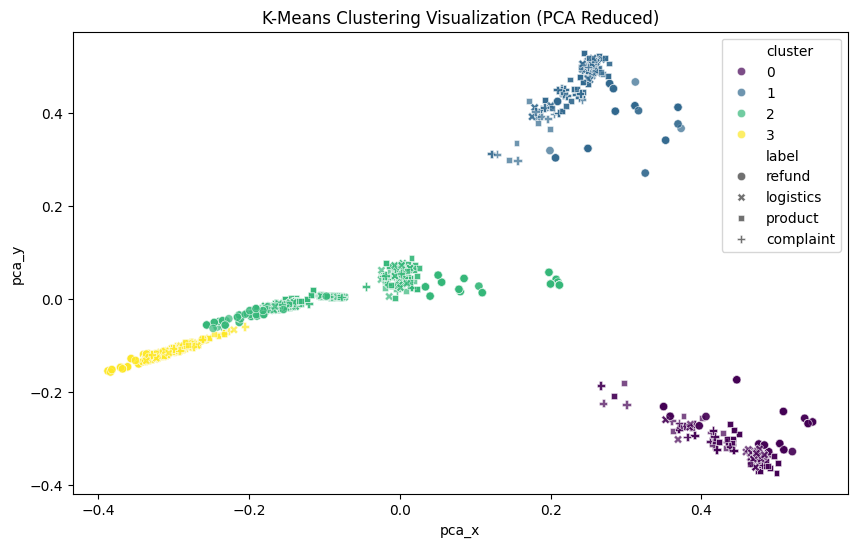

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 降维: 把 2000维 -> 2维 (PCA)
# 注意: PCA 不支持稀疏矩阵，要先 .toarray()
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vec.toarray())

# 2. 把降维结果放进 DataFrame 方便画图
df_plot = df.copy()
df_plot['pca_x'] = X_pca[:, 0]
df_plot['pca_y'] = X_pca[:, 1]
df_plot['cluster'] = kmeans.labels_ # 确保 cluster 标签对齐

# 3. 可视化
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='pca_x',
    y='pca_y',
    hue='cluster',     # 颜色区分 Cluster
    palette='viridis', # 配色方案
    style='label',     # 形状区分 真实Label (看看聚类准不准)
    alpha=0.7          # 透明度
)
plt.title('K-Means Clustering Visualization (PCA Reduced)')
plt.show()

In [13]:
# 🔍 为什么聚类效果不好？让我们来做个“亲子鉴定” (Hypothesis Testing)
# 猜测：TF-IDF 是基于词的 (Word-based)，不同语言的词完全不一样。
# 所以 K-Means 可能是按“语言”聚类，而不是按“意图”聚类！

import pandas as pd

print("🔸 假设验证 1: 聚类结果 vs 语言 (是不是按语言分的？)")
# 如果看到某个 Cluster 里 99% 都是某一种语言，那就实锤了！
print(pd.crosstab(index=df['language'], columns=df['cluster_label']))

print("\n🔸 假设验证 2: 聚类结果 vs 真实意图 (是不是按意图分的？)")
# 如果这个表很乱（一个 label 分散在好多 cluster 里），说明意图聚类失败
print(pd.crosstab(index=df['label'], columns=df['cluster_label']))

# 💡 结论预测：您会发现 Cluster 几乎完全对应 Language。
# 🚀 解决方案：对于多语言聚类，必须使用多语言 Embeddings (如 BERT/LaBSE)，TF-IDF 搞不定跨语言语义对齐。

🔸 假设验证 1: 聚类结果 vs 语言 (是不是按语言分的？)
cluster_label    0    1    2    3
language                         
ar               0    0  196    0
en             294  262  270    0
es               0    0  247  150
pt               0    0  241  142
zh-tw            0    0  198    0

🔸 假设验证 2: 聚类结果 vs 真实意图 (是不是按意图分的？)
cluster_label   0   1    2   3
label                         
complaint      68  63  284  71
logistics      69  69  280  72
product        80  77  296  52
refund         77  53  292  97


In [15]:
# 🚀 Bonus 测试：只用英语数据再跑一次 K-Means
# 目的：控制变量法——消除语言差异，看能否聚出意图

df_en = df[df['language'] == 'en'].reset_index(drop=True)

# 1. 重新向量化 (只对英文)
tfidf_en = TfidfVectorizer(max_features=1000, stop_words='english')
X_en_vec = tfidf_en.fit_transform(df_en['clean_text'])

# 2. 重新聚类 (K=4 对应 4 个意图)
kmeans_en = KMeans(n_clusters=4, random_state=42)
df_en['cluster_label'] = kmeans_en.fit_predict(X_en_vec)

# 3. 再次验证 (看这次是不是按意图聚类了？)
print("🔸只对英语聚类结果：")
print(pd.crosstab(index=df_en['label'], columns=df_en['cluster_label']))

🔸只对英语聚类结果：
cluster_label    0    1   2    3
label                           
complaint        0    0   0  192
logistics        0    0   0  205
product          0  130  92    0
refund         207    0   0    0
